<a href="https://colab.research.google.com/github/PriyanshuJVM/7th-sem-final-project/blob/main/vgg16_95.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# %% Imports and Setup
import os
import shutil
import time
import cv2
import imutils
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- Google Drive Setup ---
from google.colab import drive

print("Mounting Google Drive...")
try:
    drive.mount('/content/drive', force_remount=True)
except Exception as e:
    print(f"Drive mount connection state: {e}")

# Base Shared Folder Directory from your screenshots
DRIVE_7200_ROOT = '/content/drive/MyDrive/8th/7200'

# Local processing destinations
LOCAL_BASE_DIR = 'processed_dataset'
MODEL_SAVE_DIR = 'saved_models'

os.makedirs(MODEL_SAVE_DIR, exist_ok=True)
if os.path.exists(LOCAL_BASE_DIR):
    shutil.rmtree(LOCAL_BASE_DIR)
os.makedirs(LOCAL_BASE_DIR, exist_ok=True)

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.applications.vgg19 import VGG19
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

plt.style.use('ggplot')

# %% Custom Cropping & Preprocessing Function
def crop_brain_tumor(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (5,5), 0)

    thres = cv2.threshold(gray, 45, 255, cv2.THRESH_BINARY)[1]
    thres = cv2.erode(thres, None, iterations=2)
    thres = cv2.dilate(thres, None, iterations=2)

    cnts = cv2.findContours(thres.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cnts = imutils.grab_contours(cnts)

    if len(cnts) == 0:
        return image

    c = max(cnts, key=cv2.contourArea)
    extLeft = tuple(c[c[:,:,0].argmin()][0])
    extRight = tuple(c[c[:,:,0].argmax()][0])
    extTop = tuple(c[c[:,:,1].argmin()][0])
    extBot = tuple(c[c[:,:,1].argmax()][0])

    new_image = image[extTop[1]:extBot[1], extLeft[0]:extRight[0]]
    return new_image if new_image.size > 0 else image

# %% Image Processor and Augmenter Loop
# Reads directly from your structured drive paths, applies cropping, and outputs to clean working directories
def process_and_augment_split(drive_split_name, local_split_name, n_aug_yes=6, n_aug_no=9):
    print(f"\nProcessing partition subset: {drive_split_name} -> {local_split_name}")

    # Locate exact case variations on drive paths dynamically
    drive_split_path = os.path.join(DRIVE_7200_ROOT, drive_split_name)
    if not os.path.exists(drive_split_path):
        # Fallback if folder casing is different (e.g. lowercase 'training')
        items = os.listdir(DRIVE_7200_ROOT)
        matched = next((i for i in items if i.lower() == drive_split_name.lower()), None)
        if matched:
            drive_split_path = os.path.join(DRIVE_7200_ROOT, matched)
        else:
            raise FileNotFoundError(f"Could not locate folder partition branch: {drive_split_name}")

    drive_items = os.listdir(drive_split_path)
    yes_src = os.path.join(drive_split_path, next((i for i in drive_items if i.lower() == 'yes'), 'yes'))
    no_src = os.path.join(drive_split_path, next((i for i in drive_items if i.lower() == 'no'), 'no'))

    # Local output targets
    local_yes_dst = os.path.join(LOCAL_BASE_DIR, local_split_name, 'yes')
    local_no_dst = os.path.join(LOCAL_BASE_DIR, local_split_name, 'no')
    os.makedirs(local_yes_dst, exist_ok=True)
    os.makedirs(local_no_dst, exist_ok=True)

    data_gen = ImageDataGenerator(rotation_range=10, width_shift_range=0.1, height_shift_range=0.1,
                                  shear_range=0.1, brightness_range=(0.3, 1.0),
                                  horizontal_flip=True, vertical_flip=True, fill_mode='nearest')

    # Process files
    for src_dir, dst_dir, n_samples, prefix in [(yes_src, local_yes_dst, n_aug_yes, 'Y'), (no_src, local_no_dst, n_aug_no, 'N')]:
        img_idx = 1
        for filename in os.listdir(src_dir):
            if not filename.lower().endswith(('.png', '.jpg', '.jpeg')):
                continue

            img = cv2.imread(os.path.join(src_dir, filename))
            if img is None:
                continue

            # Crop and standardize base dimensions
            img = crop_brain_tumor(img)
            img = cv2.resize(img, (240, 240))

            # Save the clean cropped original
            cv2.imwrite(os.path.join(dst_dir, f"{prefix}_{img_idx}.jpg"), img)
            img_idx += 1

            # Generate specified augmentation samples to balance subsets
            img_tensor = img.reshape((1,) + img.shape)
            aug_counter = 0
            for batch in data_gen.flow(x=img_tensor, batch_size=1, save_to_dir=dst_dir,
                                       save_prefix=f"aug_{prefix}_{img_idx}", save_format="jpg"):
                aug_counter += 1
                if aug_counter >= n_samples:
                    break

    print(f"Completed '{local_split_name}': Yes={len(os.listdir(local_yes_dst))} images, No={len(os.listdir(local_no_dst))} images.")

# Execute pipelines mapping your Drive splits to model partitions
start_time = time.time()
process_and_augment_split('Training', 'train', n_aug_yes=6, n_aug_no=9)
# We don't augment validation/testing datasets to ensure metrics reflect real-world evaluations
process_and_augment_split('Testing', 'val', n_aug_yes=0, n_aug_no=0)
process_and_augment_split('Testing', 'test', n_aug_yes=0, n_aug_no=0)

print(f"\nData processing and ingestion pipeline finalized in: {(time.time() - start_time)/60:.2f} minutes.")

# %% Configuration Generators & Flow Iterators
train_datagen = ImageDataGenerator(rescale=1./255, horizontal_flip=0.4, vertical_flip=0.4,
                                   rotation_range=40, shear_range=0.2, width_shift_range=0.4,
                                   height_shift_range=0.4, fill_mode='nearest')
test_data_gen = ImageDataGenerator(rescale=1.0/255)

train_generator = train_datagen.flow_from_directory(os.path.join(LOCAL_BASE_DIR, 'train'),
                                                    batch_size=32, target_size=(240,240), class_mode='categorical')
valid_generator = test_data_gen.flow_from_directory(os.path.join(LOCAL_BASE_DIR, 'val'),
                                                    batch_size=32, target_size=(240,240), class_mode='categorical')
test_generator = test_data_gen.flow_from_directory(os.path.join(LOCAL_BASE_DIR, 'test'),
                                                   batch_size=32, target_size=(240,240), class_mode='categorical', shuffle=False)

# %% VGG19 Transfer Learning Architecture Setup
base_model = VGG19(input_shape=(240,240,3), include_top=False, weights='imagenet')
for layer in base_model.layers:
    layer.trainable = False

# Fully Connected Classification Dense Head
x = base_model.output
flat = Flatten()(x)
class_1 = Dense(4608, activation='relu')(flat)
drop_out = Dropout(0.2)(class_1)
class_2 = Dense(1152, activation='relu')(drop_out)
output = Dense(2, activation='softmax')(class_2)

model_01 = Model(base_model.input, output)

# Evaluation Callbacks
filepath = os.path.join(MODEL_SAVE_DIR, 'vgg19_best_frozen.h5')
es = EarlyStopping(monitor='val_loss', mode='min', patience=4, verbose=1)
cp = ModelCheckpoint(filepath, monitor='val_accuracy', save_best_only=True, verbose=1)
lrr = ReduceLROnPlateau(monitor='val_accuracy', patience=3, factor=0.5, min_lr=0.0001, verbose=1)

sgd = SGD(learning_rate=0.0001, momentum=0.9, nesterov=True)
model_01.compile(loss='categorical_crossentropy', optimizer=sgd, metrics=['accuracy'])

# %% Stage 1 Optimization: Training Frozen Feature Extraction Base
print("\n--- Training the Frozen Base Model ---")
history_01 = model_01.fit(train_generator, epochs=15, callbacks=[es, cp, lrr], validation_data=valid_generator)

print("\nEvaluating Frozen Base Weights Model on Target Test Partition:")
model_01.evaluate(test_generator)

# %% Stage 2 Optimization: Fine-Tuning Top Convolution Blocks
print("\n--- Unfreezing VGG19 Block 5 Sub-Layers for Fine-Tuning ---")
set_trainable = False
for layer in base_model.layers:
    if layer.name in ['block5_conv4', 'block5_conv3']:
        set_trainable = True
    layer.trainable = set_trainable

sgd_fine = SGD(learning_rate=0.00001, momentum=0.9, nesterov=True)
model_01.compile(loss='categorical_crossentropy', optimizer=sgd_fine, metrics=['accuracy'])

filepath_fine = os.path.join(MODEL_SAVE_DIR, 'vgg19_finetuned_best.h5')
cp_fine = ModelCheckpoint(filepath_fine, monitor='val_accuracy', save_best_only=True, verbose=1)

print("Running Fine-Tuning Optimization Loops...")
history_02 = model_01.fit(train_generator, epochs=10, callbacks=[es, cp_fine, lrr], validation_data=valid_generator)

print("\nEvaluating Final Fine-Tuned Configuration on Target Test Partition:")
model_01.evaluate(test_generator)
print("\nPipeline execution sequence complete! Saved model files can be located under 'saved_models/'.")

Mounting Google Drive...
Mounted at /content/drive

Processing partition subset: Training -> train
Completed 'train': Yes=29504 images, No=13994 images.

Processing partition subset: Testing -> val
Completed 'val': Yes=2400 images, No=800 images.

Processing partition subset: Testing -> test
Completed 'test': Yes=2400 images, No=800 images.

Data processing and ingestion pipeline finalized in: 14.63 minutes.
Found 43498 images belonging to 2 classes.
Found 3200 images belonging to 2 classes.
Found 3200 images belonging to 2 classes.

--- Training the Frozen Base Model ---
Epoch 1/15
1360/1360 ━━━━━━━━━━━━━━━━━━━━ 0s 583ms/step - accuracy: 0.8232 - loss: 0.4080
Epoch 1: val_accuracy improved from None to 0.94531, saving model to saved_models/vgg19_best_frozen.h5



Epoch 1: finished saving model to saved_models/vgg19_best_frozen.h5
1360/1360 ━━━━━━━━━━━━━━━━━━━━ 850s 612ms/step - accuracy: 0.8745 - loss: 0.3154 - val_accuracy: 0.9453 - val_loss: 0.1497 - learning_rate: 1.0000e-04
Epoch 2/15
1360/1360 ━━━━━━━━━━━━━━━━━━━━ 0s 585ms/step - accuracy: 0.9188 - loss: 0.2127
Epoch 2: val_accuracy improved from 0.94531 to 0.95156, saving model to saved_models/vgg19_best_frozen.h5



Epoch 2: finished saving model to saved_models/vgg19_best_frozen.h5
1360/1360 ━━━━━━━━━━━━━━━━━━━━ 836s 615ms/step - accuracy: 0.9202 - loss: 0.2103 - val_accuracy: 0.9516 - val_loss: 0.1349 - learning_rate: 1.0000e-04
Epoch 3/15
1360/1360 ━━━━━━━━━━━━━━━━━━━━ 0s 580ms/step - accuracy: 0.9268 - loss: 0.1982
Epoch 3: val_accuracy did not improve from 0.95156
1360/1360 ━━━━━━━━━━━━━━━━━━━━ 813s 598ms/step - accuracy: 0.9284 - loss: 0.1912 - val_accuracy: 0.9494 - val_loss: 0.1473 - learning_rate: 1.0000e-04
Epoch 4/15
1360/1360 ━━━━━━━━━━━━━━━━━━━━ 0s 581ms/step - accuracy: 0.9332 - loss: 0.1801
Epoch 4: val_accuracy did not improve from 0.95156
1360/1360 ━━━━━━━━━━━━━━━━━━━━ 813s 598ms/step - accuracy: 0.9329 - loss: 0.1807 - val_accuracy: 0.9450 - val_loss: 0.1604 - learning_rate: 1.0000e-04
Epoch 5/15
1360/1360 ━━━━━━━━━━━━━━━━━━━━ 0s 579ms/step - accuracy: 0.9348 - loss: 0.1764
Epoch 5: val_accuracy did not improve from 0.95156
1360/1360 ━━━━━━━━━━━━━━━━━━━━ 812s 596ms/step - accura


Epoch 6: finished saving model to saved_models/vgg19_best_frozen.h5
1360/1360 ━━━━━━━━━━━━━━━━━━━━ 830s 610ms/step - accuracy: 0.9365 - loss: 0.1686 - val_accuracy: 0.9531 - val_loss: 0.1376 - learning_rate: 1.0000e-04
Epoch 6: early stopping

Evaluating Frozen Base Weights Model on Target Test Partition:
100/100 ━━━━━━━━━━━━━━━━━━━━ 26s 256ms/step - accuracy: 0.9550 - loss: 0.1419

--- Unfreezing VGG19 Block 5 Sub-Layers for Fine-Tuning ---
Running Fine-Tuning Optimization Loops...
Epoch 1/10
1360/1360 ━━━━━━━━━━━━━━━━━━━━ 0s 598ms/step - accuracy: 0.9411 - loss: 0.1660
Epoch 1: val_accuracy improved from None to 0.95187, saving model to saved_models/vgg19_finetuned_best.h5



Epoch 1: finished saving model to saved_models/vgg19_finetuned_best.h5
1360/1360 ━━━━━━━━━━━━━━━━━━━━ 863s 628ms/step - accuracy: 0.9436 - loss: 0.1560 - val_accuracy: 0.9519 - val_loss: 0.1402 - learning_rate: 1.0000e-05
Epoch 2/10
1360/1360 ━━━━━━━━━━━━━━━━━━━━ 0s 590ms/step - accuracy: 0.9453 - loss: 0.1512
Epoch 2: val_accuracy did not improve from 0.95187
1360/1360 ━━━━━━━━━━━━━━━━━━━━ 830s 610ms/step - accuracy: 0.9459 - loss: 0.1490 - val_accuracy: 0.9481 - val_loss: 0.1692 - learning_rate: 1.0000e-05
Epoch 3/10
1360/1360 ━━━━━━━━━━━━━━━━━━━━ 0s 597ms/step - accuracy: 0.9476 - loss: 0.1440
Epoch 3: val_accuracy improved from 0.95187 to 0.95531, saving model to saved_models/vgg19_finetuned_best.h5



Epoch 3: finished saving model to saved_models/vgg19_finetuned_best.h5
1360/1360 ━━━━━━━━━━━━━━━━━━━━ 845s 621ms/step - accuracy: 0.9490 - loss: 0.1418 - val_accuracy: 0.9553 - val_loss: 0.1446 - learning_rate: 1.0000e-05
Epoch 4/10
1360/1360 ━━━━━━━━━━━━━━━━━━━━ 0s 590ms/step - accuracy: 0.9517 - loss: 0.1326
Epoch 4: val_accuracy improved from 0.95531 to 0.95656, saving model to saved_models/vgg19_finetuned_best.h5



Epoch 4: finished saving model to saved_models/vgg19_finetuned_best.h5
1360/1360 ━━━━━━━━━━━━━━━━━━━━ 840s 618ms/step - accuracy: 0.9521 - loss: 0.1337 - val_accuracy: 0.9566 - val_loss: 0.1415 - learning_rate: 1.0000e-05
Epoch 4: early stopping

Evaluating Final Fine-Tuned Configuration on Target Test Partition:
100/100 ━━━━━━━━━━━━━━━━━━━━ 26s 256ms/step - accuracy: 0.9597 - loss: 0.1448

Pipeline execution sequence complete! Saved model files can be located under 'saved_models/'.



Loading the best fine-tuned model for final evaluation...



Final Evaluation of the best fine-tuned model on the Test Partition:
100/100 ━━━━━━━━━━━━━━━━━━━━ 22s 207ms/step - accuracy: 0.9597 - loss: 0.1448
Test Loss: 0.1448
Test Accuracy: 0.9597

Generating Training History Plots...


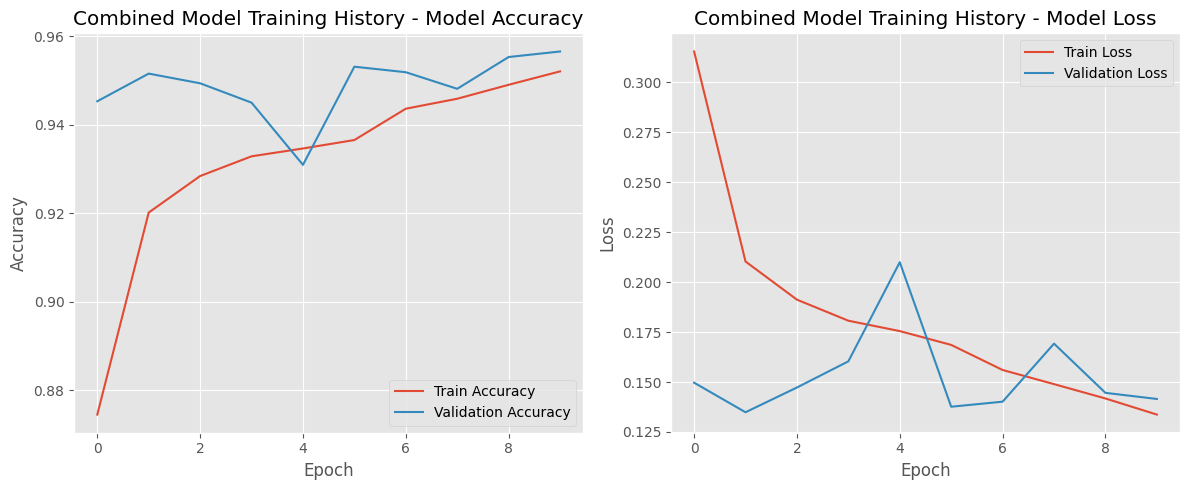

In [3]:
from tensorflow.keras.models import load_model

# Load the best fine-tuned model
print("\nLoading the best fine-tuned model for final evaluation...")
best_model = load_model(filepath_fine)

# Evaluate the loaded model on the test set
print("\nFinal Evaluation of the best fine-tuned model on the Test Partition:")
loss, accuracy = best_model.evaluate(test_generator)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")


# Combine training histories for plotting
hist_df_01 = pd.DataFrame(history_01.history)
hist_df_02 = pd.DataFrame(history_02.history)

# Adjust epoch numbers for the second stage
hist_df_02.index = hist_df_02.index + len(hist_df_01)

combined_history_df = pd.concat([hist_df_01, hist_df_02])

# Plotting function
def plot_history(history_df, title):
    plt.figure(figsize=(12, 5))

    # Plot training & validation accuracy values
    plt.subplot(1, 2, 1)
    plt.plot(history_df['accuracy'], label='Train Accuracy')
    plt.plot(history_df['val_accuracy'], label='Validation Accuracy')
    plt.title(f'{title} - Model Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(loc='lower right')

    # Plot training & validation loss values
    plt.subplot(1, 2, 2)
    plt.plot(history_df['loss'], label='Train Loss')
    plt.plot(history_df['val_loss'], label='Validation Loss')
    plt.title(f'{title} - Model Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

print("\nGenerating Training History Plots...")
plot_history(combined_history_df, 'Combined Model Training History')


Generating predictions on the test set...
100/100 ━━━━━━━━━━━━━━━━━━━━ 22s 212ms/step

--- Confusion Matrix ---


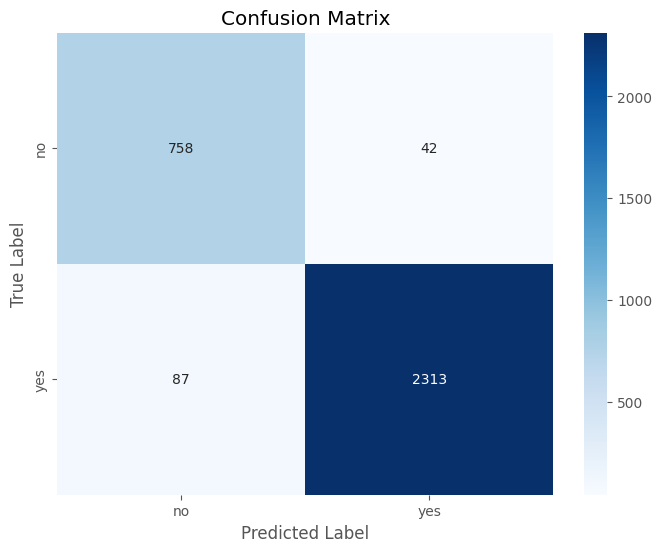


--- Classification Report (Precision, Recall, F1-Score) ---
              precision    recall  f1-score   support

          no       0.90      0.95      0.92       800
         yes       0.98      0.96      0.97      2400

    accuracy                           0.96      3200
   macro avg       0.94      0.96      0.95      3200
weighted avg       0.96      0.96      0.96      3200


Saving the best fine-tuned model to: /content/drive/MyDrive/8th/vgg19_finetuned_best.h5
Model saved successfully to Google Drive!


In [4]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

print("\nGenerating predictions on the test set...")
# Get predictions
y_pred_probs = best_model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)

# Get true labels
y_true = test_generator.classes

# Get class labels from the generator
class_labels = list(test_generator.class_indices.keys())

print("\n--- Confusion Matrix ---")
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

print("\n--- Classification Report (Precision, Recall, F1-Score) ---")
report = classification_report(y_true, y_pred, target_names=class_labels)
print(report)

# Save the fine-tuned model to Google Drive
drive_save_path = os.path.join('/content/drive/MyDrive/8th/', 'vgg19_finetuned_best.h5')
print(f"\nSaving the best fine-tuned model to: {drive_save_path}")
best_model.save(drive_save_path)
print("Model saved successfully to Google Drive!")

In [5]:
# Displaying the confusion matrix and classification report
print("--- Confusion Matrix ---")
print(cm)

print("\n--- Classification Report (Precision, Recall, F1-Score) ---")
print(report)

print(f"\nFinal Test Loss: {loss:.4f}")
print(f"Final Test Accuracy: {accuracy:.4f}")

--- Confusion Matrix ---
[[ 758   42]
 [  87 2313]]

--- Classification Report (Precision, Recall, F1-Score) ---
              precision    recall  f1-score   support

          no       0.90      0.95      0.92       800
         yes       0.98      0.96      0.97      2400

    accuracy                           0.96      3200
   macro avg       0.94      0.96      0.95      3200
weighted avg       0.96      0.96      0.96      3200


Final Test Loss: 0.1448
Final Test Accuracy: 0.9597
